# 🚀 YOLOv11x Training Pipeline - Detección de Logos (Google Drive)

## 🎯 Objetivo
Este notebook entrena un modelo **YOLOv11x (Extra Large)** para detectar logos de empresas, utilizando un dataset personalizado.
Se ejecuta en la nube (**Google Colab**) aprovechando las GPUs Tesla T4, con una estrategia de **persistencia en Google Drive** para evitar pérdidas de datos por desconexión.

## 📝 Contenido
1.  **Conexión a Drive:** Montaje de unidad para persistencia de datos.
2.  **Verificación del Entorno:** GPU y librerías.
3.  **Exploración del Dataset (EDA):** Análisis de estructura y visualización.
4.  **Configuración:** Definición detallada de hiperparámetros (Batch size, Epochs, etc.).
5.  **Entrenamiento:** Ejecución con reanudación automática (Resume).
6.  **Análisis de Resultados:** Interpretación profunda de métricas y curvas de pérdida.
7.  **Validación e Inferencia:** Pruebas visuales.
8.  **Exportación:** Guardado de pesos finales.

## ⚠️ Requisitos Previos
1.  Tener `dataset_yolov8.zip` en tu Google Drive.
2.  Activar GPU en Colab (Entorno de ejecución -> Cambiar tipo de entorno -> T4 GPU).

---

## 1. 🔌 Conexión y Gestión de Datos (Drive)

Montamos Google Drive para que actúe como nuestro disco duro persistente. Esto es crucial porque Colab borra todo al cerrarse. Al usar Drive, si el entrenamiento se corta, los checkpoints (`last.pt`) quedan guardados y podemos continuar automáticamente.

In [1]:
from google.colab import drive
import os

# =============================================================================
# Drive Mounting
# =============================================================================
drive.mount('/content/drive')

# Rutas en tu Google Drive (Ajusta si tienes el ZIP en otro lado)
DRIVE_ZIP_PATH = "/content/drive/MyDrive/dataset_yolov8.zip"
DRIVE_PROJECT_PATH = "/content/drive/MyDrive/YOLO_Trainings/PXII_G3_CV"

print(f"📂 Dataset origen (Drive): {DRIVE_ZIP_PATH}")
print(f"💾 Carpeta de proyecto (Drive): {DRIVE_PROJECT_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📂 Dataset origen (Drive): /content/drive/MyDrive/dataset_yolov8.zip
💾 Carpeta de proyecto (Drive): /content/drive/MyDrive/YOLO_Trainings/PXII_G3_CV


In [2]:
import os
print("Buscando carpetas en tu Drive...")
for root, dirs, files in os.walk("/content/drive/MyDrive"):
    if "yolo11x_drive_run" in dirs:
        print(f"✅ ¡ENCONTRADO AQUÍ!: {os.path.join(root, 'yolo11x_drive_run')}")

Buscando carpetas en tu Drive...
✅ ¡ENCONTRADO AQUÍ!: /content/drive/MyDrive/YOLO_Trainings/PXII_G3_CV/runs/detect/yolo11x_drive_run


## 2. 🔧 Verificación del Entorno

Primero comprobamos que el entorno tiene acceso a la GPU y que todas las librerías necesarias están instaladas correctamente.
Es ideal que nos toque una **Tesla T4** (16GB VRAM) o superior para entrenar YOLOv11x.

In [3]:
# =============================================================================
# Environment Verification
# =============================================================================
# This cell checks that all required libraries are installed and that
# the GPU is accessible for training.
# =============================================================================
# Instalar Ultralytics si no existe
!pip install ultralytics -q

import zipfile
import yaml
import cv2
import torch
import ultralytics
import pandas as pd
import matplotlib.pyplot as plt
import glob
import shutil
from datetime import datetime
from IPython.display import Image, display, clear_output

# Configurar matplotlib
%matplotlib inline

print(f"✅ Ultralytics version: {ultralytics.__version__}")
print(f"✅ PyTorch version: {torch.__version__}")

# Comprobación de GPU
if torch.cuda.is_available():
    gpu_info = torch.cuda.get_device_properties(0)
    print(f"🚀 GPU Detectada: {gpu_info.name} ({gpu_info.total_memory/1e9:.2f} GB VRAM)")
else:
    print("❌ ERROR: No se detecta GPU. Actívala en 'Entorno de ejecución' -> 'Cambiar tipo de entorno'.")

✅ Ultralytics version: 8.4.9
✅ PyTorch version: 2.9.0+cu126
🚀 GPU Detectada: Tesla T4 (15.83 GB VRAM)


## 3. 📁 Exploración del Dataset

Analizamos la estructura del dataset descomprimido. Aunque guardamos los resultados en Drive, leer miles de imágenes pequeñas desde Drive es **muy lento**. Por eso, descomprimimos el dataset en el disco local temporal de Colab (`/content/dataset_yolov8`).

In [4]:
# =============================================================================
# Dataset Extraction (Optimized for Speed)
# =============================================================================
LOCAL_DATASET_DIR = "/content/dataset_yolov8"

if not os.path.exists(LOCAL_DATASET_DIR):
    print("📂 Descomprimiendo dataset en disco local (para velocidad)...")
    if os.path.exists(DRIVE_ZIP_PATH):
        with zipfile.ZipFile(DRIVE_ZIP_PATH, 'r') as zip_ref:
            # Lógica inteligente para detectar si el ZIP tiene carpeta raíz o no
            top_level = {x.split('/')[0] for x in zip_ref.namelist() if '/' in x}
            extract_to = "/content/" if "dataset_yolov8" in top_level else "/content/dataset_yolov8/"
            zip_ref.extractall(extract_to)
        print("✅ Descompresión completada.")
    else:
        print(f"❌ ERROR: No encuentro {DRIVE_ZIP_PATH}. Verifica tu Drive.")
else:
    print("ℹ️ El dataset ya está listo en local.")

ℹ️ El dataset ya está listo en local.


### 3.1 Análisis del archivo data.yaml

El archivo `data.yaml` contiene la configuración del dataset, incluyendo las rutas a las imágenes y la lista de clases a detectar.

In [5]:
# Localizar archivo de configuración data.yaml
EXTRACT_DIR = LOCAL_DATASET_DIR
found_yaml = None

for root, dirs, files in os.walk("/content/"):
    if "data.yaml" in files:
        EXTRACT_DIR = root
        found_yaml = os.path.join(root, "data.yaml")
        break

if found_yaml:
    # Crear YAML específico para Colab con rutas absolutas
    COLAB_YAML = os.path.join(EXTRACT_DIR, "data_yolo11x_colab.yaml")
    with open(found_yaml, 'r') as f:
        config = yaml.safe_load(f)

    # Parse data.yaml Configuration
    # - train: path to training images
    # - val: path to validation images
    # - nc: number of classes
    # - names: list of class names
    config['path'] = EXTRACT_DIR
    config['train'] = "train/images"
    config['val'] = "valid/images"
    config['test'] = "test/images"

    with open(COLAB_YAML, 'w') as f:
        yaml.dump(config, f)

    print(f"✅ Configuración YAML lista: {COLAB_YAML}")
    print(f"📊 Clases (nc): {config.get('nc', 'Unknown')}")
else:
    print("❌ ERROR CRÍTICO: No se encuentra data.yaml.")

✅ Configuración YAML lista: /content/dataset_yolov8/data_yolo11x_colab.yaml
📊 Clases (nc): 175


### 3.2 Visualización de Imágenes de Ejemplo

Mostramos algunas imágenes de entrenamiento para verificar que el dataset se ha descomprimido correctamente y las rutas son válidas antes de iniciar el entrenamiento masivo.

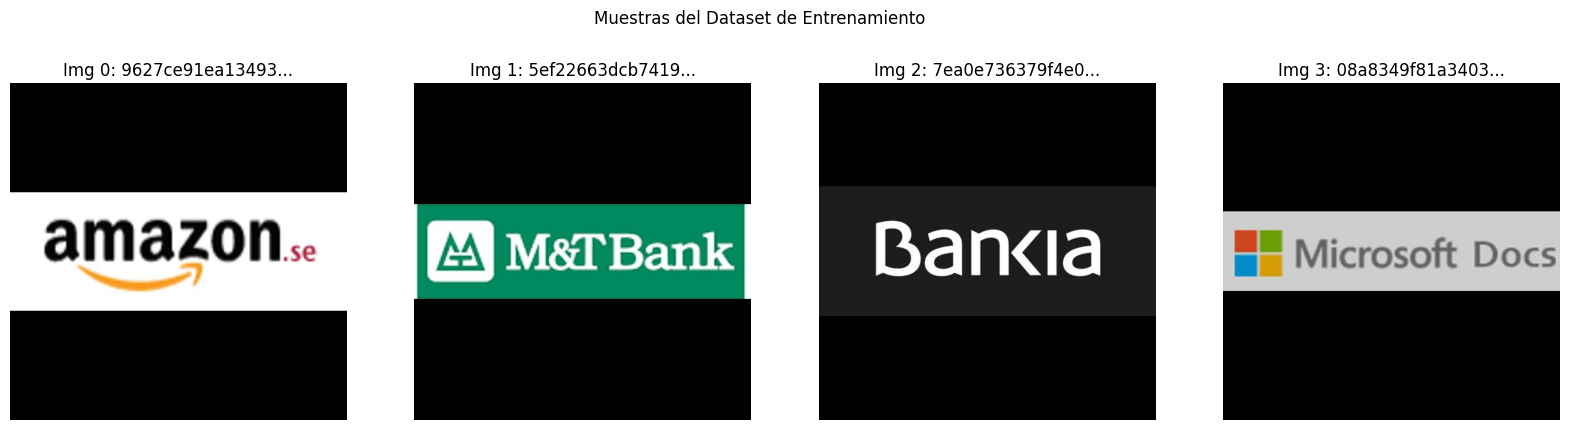

In [6]:
# =============================================================================
# Sample Image Visualization
# =============================================================================
# Display a grid of training images to visually inspect the dataset.
# This helps identify potential issues with images or paths.
# =============================================================================
train_imgs = glob.glob(f"{EXTRACT_DIR}/train/images/*.jpg")

if len(train_imgs) > 0:
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle("Muestras del Dataset de Entrenamiento")
    for i in range(4):
        if i < len(train_imgs):
            img = cv2.imread(train_imgs[i])
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[i].imshow(img)
            axes[i].axis('off')
            axes[i].set_title(f"Img {i}: {os.path.basename(train_imgs[i])[:15]}...")
    plt.show()
else:
    print("⚠️ No se encontraron imágenes para visualizar.")

## 4. ⚙️ Configuración de Hiperparámetros

Definimos los parámetros clave para el entrenamiento del modelo **YOLOv11x**.

### Explicación de Parámetros Clave:

| Parámetro | Valor Sugerido | Descripción |
|-----------|----------------|-------------|
| **MODEL** | `yolo11x.pt` | Variante "Extra Large" (~56M params). La más precisa y lenta. |
| **EPOCHS** | `100` | Número de veces que el modelo ve todo el dataset. Más épocas = mejor aprendizaje (hasta cierto punto). |
| **BATCH** | `8` | Número de imágenes procesadas a la vez. En T4 (16GB VRAM), 8 es seguro para YOLO11x. |
| **IMGSZ** | `640` | Resolución a la que se redimensionan las imágenes. Mayor = más detalle pero más memoria GPU. |
| **PATIENCE**| `15` | Épocas sin mejora antes de detener el entrenamiento (Early Stopping) para evitar overfitting. |
| **WORKERS** | `8` | Procesos paralelos para cargar datos. Colab tiene buena CPU, 8 es óptimo. |
| **RESUME** | `Auto` | **Crucial:** Si existe un entrenamiento previo en Drive, lo detecta y continúa. |

In [7]:
# =============================================================================
# Training Hyperparameters Configuration
# =============================================================================
MODEL_NAME = "yolo11x.pt"  # Extra Large Model
EXPERIMENT_NAME = "yolo11x_drive_run"

# Directorio en Drive donde se guardarán los pesos y logs
PROJECT_DIR = f"{DRIVE_PROJECT_PATH}/runs/detect"

EPOCHS = 100
BATCH_SIZE = 8        # Ajustado para Tesla T4 (Si da error de memoria, bajar a 4)
IMAGE_SIZE = 640
PATIENCE = 15
WORKERS = 8

# Lógica de Reanudación Automática (Resume)
last_checkpoint = f"{PROJECT_DIR}/{EXPERIMENT_NAME}/weights/last.pt"
RESUME = False
MODEL_TO_TRAIN = MODEL_NAME

if os.path.exists(last_checkpoint):
    print(f"♻️ DETECTADO CHECKPOINT PREVIO EN DRIVE: {last_checkpoint}")
    print("   -> Se activará el modo RESUME para continuar el entrenamiento.")
    RESUME = True
    MODEL_TO_TRAIN = last_checkpoint
else:
    print("🆕 Iniciando NUEVO entrenamiento desde cero.")

# Imprimir resumen de configuración
print("="*60)
print(f"🚀 CONFIGURACIÓN DE ENTRENAMIENTO")
print("="*60)
print(f" Modelo Base: {MODEL_TO_TRAIN}")
print(f" Épocas:      {EPOCHS}")
print(f" Batch Size:  {BATCH_SIZE}")
print(f" Image Size:  {IMAGE_SIZE}")
print(f" Output Dir:  {PROJECT_DIR}/{EXPERIMENT_NAME}")
print("="*60)

♻️ DETECTADO CHECKPOINT PREVIO EN DRIVE: /content/drive/MyDrive/YOLO_Trainings/PXII_G3_CV/runs/detect/yolo11x_drive_run/weights/last.pt
   -> Se activará el modo RESUME para continuar el entrenamiento.
🚀 CONFIGURACIÓN DE ENTRENAMIENTO
 Modelo Base: /content/drive/MyDrive/YOLO_Trainings/PXII_G3_CV/runs/detect/yolo11x_drive_run/weights/last.pt
 Épocas:      100
 Batch Size:  8
 Image Size:  640
 Output Dir:  /content/drive/MyDrive/YOLO_Trainings/PXII_G3_CV/runs/detect/yolo11x_drive_run


## 5. 🏋️ Entrenamiento del Modelo

Iniciamos el ciclo de entrenamiento. Ultralytics se encargará de todo el proceso: carga de datos, optimización, validación y checkpointing.

### Interpretación de los Logs en tiempo real:

| Métrica | Significado | Objetivo |
|---------|-------------|----------|
| **GPU_mem** | Memoria VRAM utilizada | No debe saturarse |
| **box_loss** | Error en la localización de la caja (bounding box) | **Debe bajar** (↓) |
| **cls_loss** | Error en la clasificación (qué objeto es) | **Debe bajar** (↓) |
| **dfl_loss** | Distribution Focal Loss (refinamiento de cajas) | **Debe bajar** (↓) |
| **Instances** | Número de objetos detectados en el batch actual | Variable |
| **Size** | Tamaño de imagen procesado | Fijo (640) |


In [8]:
from ultralytics import YOLO

# =============================================================================
# Training Execution
# =============================================================================
# This cell runs the actual training loop. The model.train() method
# handles everything: data loading, forward/backward passes, and saving to Drive.
# =============================================================================

# Cargar modelo
model = YOLO(MODEL_TO_TRAIN)

print(f"🔥 Iniciando entrenamiento de {MODEL_NAME}...")

# Ejecutar entrenamiento
results = model.train(
    data=COLAB_YAML,
    epochs=EPOCHS,
    patience=PATIENCE,
    batch=BATCH_SIZE,
    imgsz=IMAGE_SIZE,
    project=PROJECT_DIR,
    name=EXPERIMENT_NAME,
    exist_ok=True,
    save=True,          # Guarda checkpoints en Drive
    resume=RESUME,      # Continúa si se cortó
    workers=WORKERS,
    verbose=True,
    plots=True
)

🔥 Iniciando entrenamiento de yolo11x.pt...
Ultralytics 8.4.9 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset_yolov8/data_yolo11x_colab.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/YOLO_Trainings/PXII_G3_CV/runs/detect/yolo11x_drive_run/weights/last.pt, momentum=0.937, mosaic

## 6. 📊 Evaluación y Métricas

Analizamos los resultados del entrenamiento. Las métricas principales son:

| Métrica | Descripción |
|---------|-------------|
| **mAP50** | Mean Average Precision con IoU=0.50. Es la **métrica principal**. Cuanto más alta, mejor. Indica qué tan bien detecta los objetos solapándolos al menos un 50%. |
| **mAP50-95** | mAP promediada para IoU de 0.50 a 0.95. Una métrica más estricta que exige gran precisión en la caja. |
| **Precision** | % de detecciones correctas sobre el total de detecciones (Evita falsos positivos). |
| **Recall** | % de objetos reales que el modelo fue capaz de encontrar (Evita falsos negativos). |

In [9]:
# =============================================================================
# Training Results Analysis
# =============================================================================
RESULTS_DIR = f"{PROJECT_DIR}/{EXPERIMENT_NAME}"
CSV_PATH = f"{RESULTS_DIR}/results.csv"
PNG_RESULTS = f"{RESULTS_DIR}/results.png"
PNG_CONFUSION = f"{RESULTS_DIR}/confusion_matrix.png"

# 1. Mostrar mejores métricas
if os.path.exists(CSV_PATH):
    df = pd.read_csv(CSV_PATH)
    df.columns = df.columns.str.strip()
    if not df.empty:
        # Get row with best mAP50
        best_idx = df['metrics/mAP50(B)'].idxmax()
        best_row = df.loc[best_idx]
        epoch_num = df.loc[best_idx, 'epoch']

        print(f"\n🏆 MEJOR RESULTADO (Época {epoch_num}):")
        print(f"   mAP@50:    {best_row['metrics/mAP50(B)']:.4f}")
        print(f"   Precision: {best_row['metrics/precision(B)']:.4f}")
        print(f"   Recall:    {best_row['metrics/recall(B)']:.4f}")


🏆 MEJOR RESULTADO (Época 66):
   mAP@50:    0.9703
   Precision: 0.9160
   Recall:    0.8980


### 6.1 Visualización de Curvas de Entrenamiento
Mostramos las curvas generadas automáticamente por YOLO.
*   **Losses (Izquierda):** Deben bajar constantemente.
*   **Metrics (Derecha):** Deben subir y estabilizarse.


📈 Curvas de Entrenamiento:


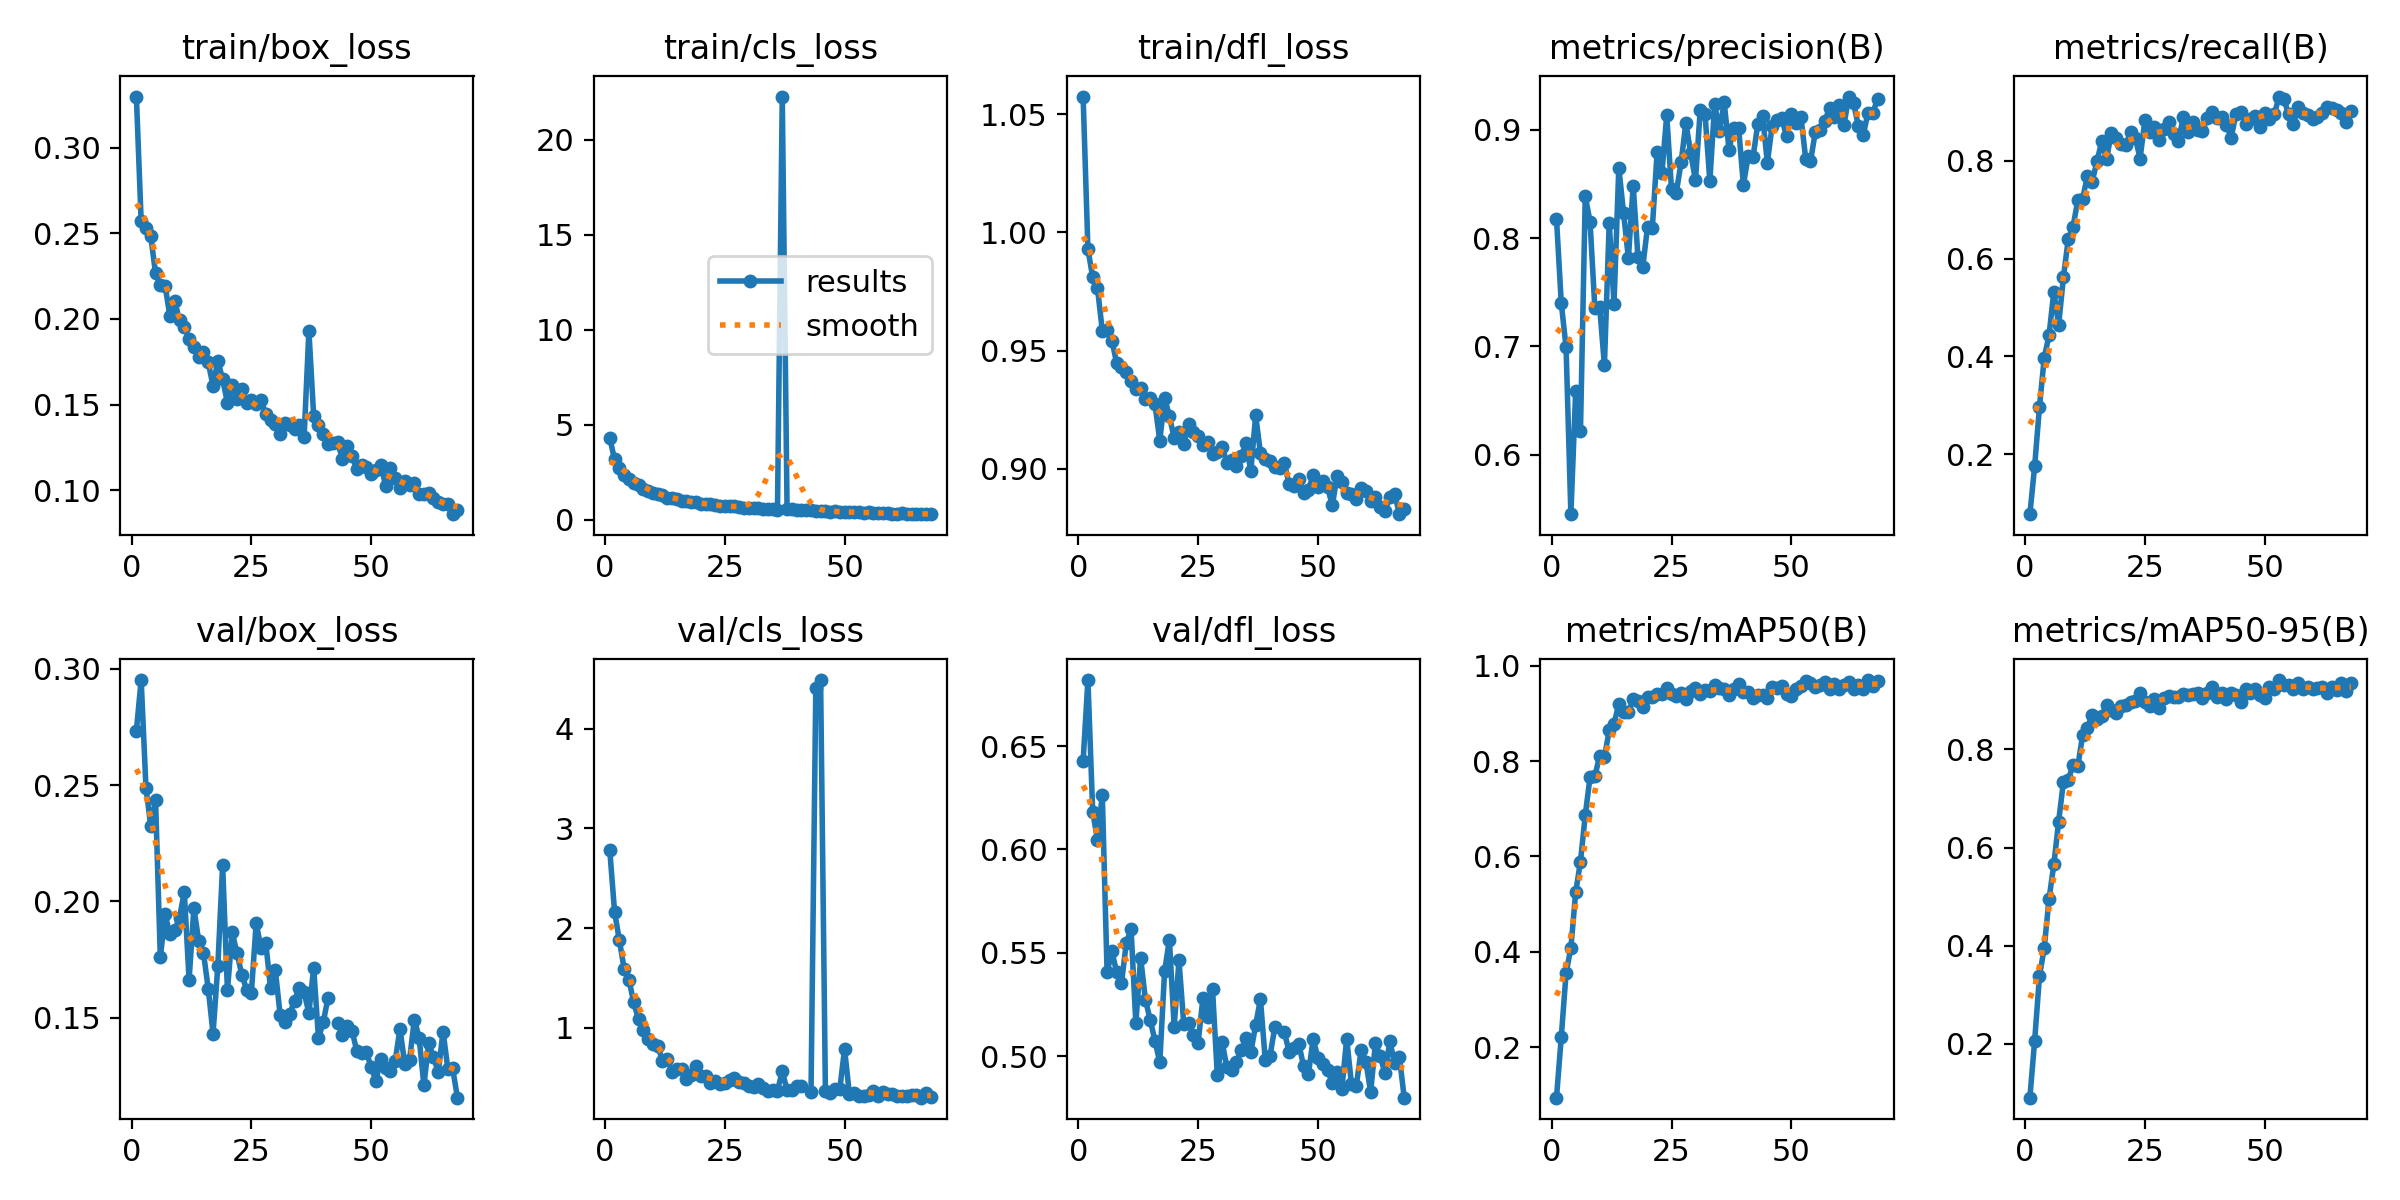


🧩 Matriz de Confusión:


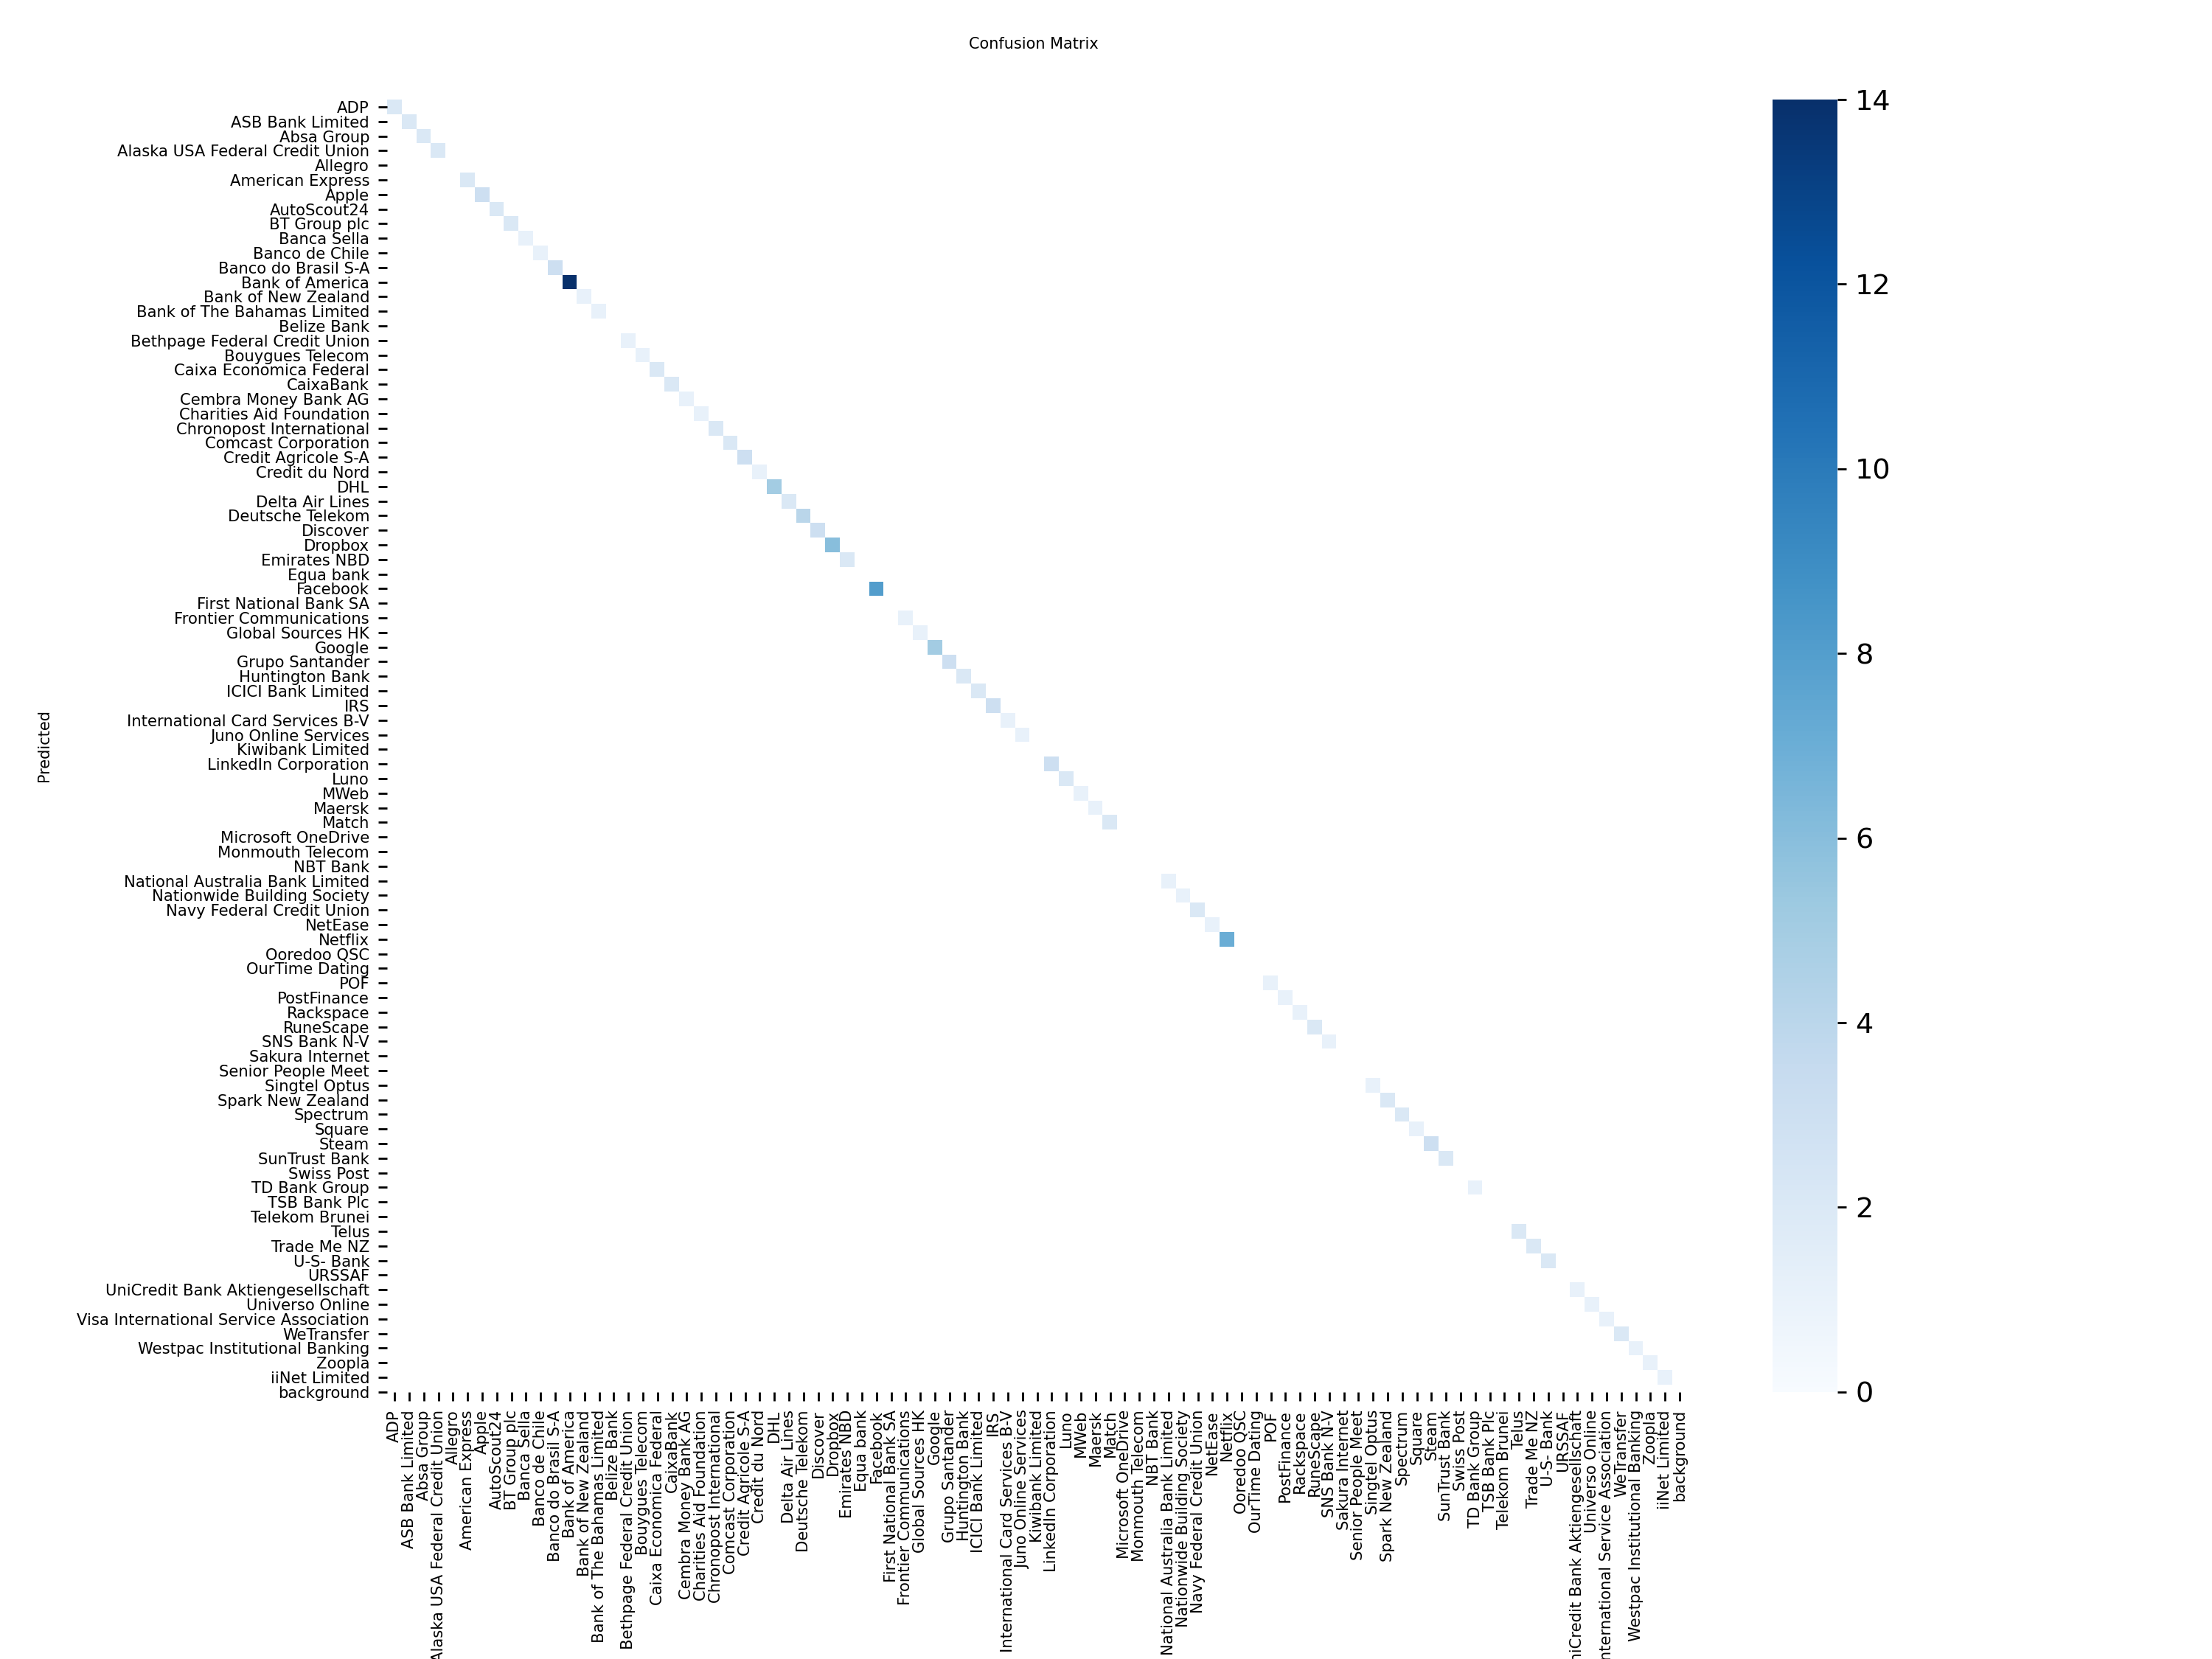

In [10]:
# =============================================================================
# Training Curves Visualization
# =============================================================================
if os.path.exists(PNG_RESULTS):
    print("\n📈 Curvas de Entrenamiento:")
    display(Image(PNG_RESULTS, width=800))

if os.path.exists(PNG_CONFUSION):
    print("\n🧩 Matriz de Confusión:")
    display(Image(PNG_CONFUSION, width=800))

### 6.2 Validación del Modelo
Ejecutamos una validación explícita sobre el conjunto de validación usando el mejor modelo guardado.

In [11]:
# =============================================================================
# Model Validation
# =============================================================================
BEST_WEIGHTS = f"{RESULTS_DIR}/weights/best.pt"

if os.path.exists(BEST_WEIGHTS):
    print(f"🧪 Validando mejor modelo: {BEST_WEIGHTS}")
    val_model = YOLO(BEST_WEIGHTS)
    metrics = val_model.val(data=COLAB_YAML)

    print(f"\n📊 Validación Final mAP50: {metrics.box.map50:.4f}")

🧪 Validando mejor modelo: /content/drive/MyDrive/YOLO_Trainings/PXII_G3_CV/runs/detect/yolo11x_drive_run/weights/best.pt
Ultralytics 8.4.9 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11x summary (fused): 191 layers, 57,029,149 parameters, 0 gradients, 195.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 763.9±310.5 MB/s, size: 15.8 KB)
val: Scanning /content/dataset_yolov8/valid/labels.cache... 402 images, 25 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 402/402 168.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 26/26 1.3s/it 33.5s
                   all        402        377      0.873      0.931      0.968      0.942
                   ADP          2          2      0.901          1      0.995      0.995
                   AOL          2          2      0.509          1      0.995      0.749
      ASB Bank Limited          2          2          1      0.612      0.995      0.949
    

## 7. 🔍 Inferencia de Prueba

Probamos el modelo entrenado (`best.pt`) con algunas imágenes del conjunto de test que el modelo nunca ha visto durante el entrenamiento. Esto nos da una idea visual de su rendimiento real.

🖼️ Visualizando predicciones...

0: 640x640 1 Credit Agricole S-A, 75.3ms
1: 640x640 (no detections), 75.3ms
2: 640x640 1 Spectrum, 75.3ms
Speed: 3.3ms preprocess, 75.3ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)


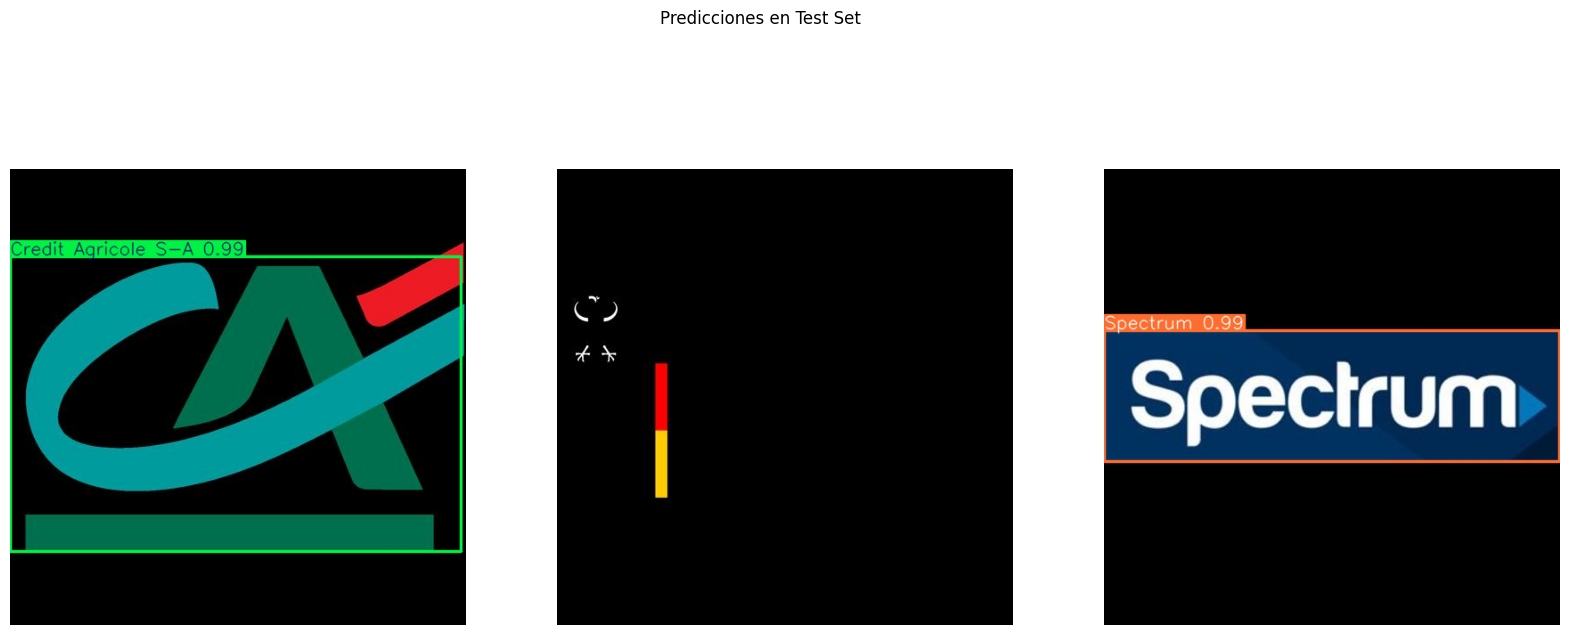

In [12]:
# =============================================================================
# Visual Inference on Test Images
# =============================================================================
TEST_IMGS = glob.glob(f"{EXTRACT_DIR}/test/images/*.jpg")[:3]

if len(TEST_IMGS) > 0 and os.path.exists(BEST_WEIGHTS):
    print(f"🖼️ Visualizando predicciones...")

    # Inferencia
    model_pred = YOLO(BEST_WEIGHTS)
    results = model_pred.predict(TEST_IMGS, conf=0.4, save=False)

    # Visualizar
    fig, axes = plt.subplots(1, 3, figsize=(20, 8))
    fig.suptitle("Predicciones en Test Set")

    for i, r in enumerate(results):
        im_rgb = cv2.cvtColor(r.plot(), cv2.COLOR_BGR2RGB)
        axes[i].imshow(im_rgb)
        axes[i].axis('off')
    plt.show()
else:
    print("⚠️ No se pudo realizar la prueba visual (faltan imágenes o pesos).")

## 8. 💾 Exportación y Resumen Final

Exportamos el modelo a formato **ONNX** para máxima compatibilidad y mostramos un resumen de dónde están todos los archivos generados.

In [13]:
# =============================================================================
# Model Export
# =============================================================================
if os.path.exists(BEST_WEIGHTS):
    print("📦 Exportando modelo a ONNX...")
    model = YOLO(BEST_WEIGHTS)
    model.export(format='onnx')
    print(f"✅ Modelo exportado: {BEST_WEIGHTS.replace('.pt', '.onnx')}")

📦 Exportando modelo a ONNX...
Ultralytics 8.4.9 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO11x summary (fused): 191 layers, 57,029,149 parameters, 0 gradients, 195.5 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/YOLO_Trainings/PXII_G3_CV/runs/detect/yolo11x_drive_run/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 179, 8400) (109.5 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 14 packages in 221ms
Prepared 6 packages in 9.98s
Installed 6 packages in 431ms
 + colorama==0.4.6
 + coloredlogs==15.0.1
 + humanfriendly==10.0
 + onnx==1.20.1
 + onnxruntime-gpu==1.23.2
 + onnxslim==0.1.82

requirements: AutoUpdate success ✅ 11.3s
WARNING ⚠️ re

/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/utils.py:1447: OnnxExporterWarning: Exporting to ONNX opset version 22 is not supported. by 'torch.onnx.export()'. The highest opset version supported is 20. To use a newer opset version, consider 'torch.onnx.export(..., dynamo=True)'. 
  warnings.warn(


ONNX: slimming with onnxslim 0.1.82...
ONNX: export success ✅ 23.0s, saved as '/content/drive/MyDrive/YOLO_Trainings/PXII_G3_CV/runs/detect/yolo11x_drive_run/weights/best.onnx' (217.9 MB)

Export complete (30.4s)
Results saved to /content/drive/MyDrive/YOLO_Trainings/PXII_G3_CV/runs/detect/yolo11x_drive_run/weights
Predict:         yolo predict task=detect model=/content/drive/MyDrive/YOLO_Trainings/PXII_G3_CV/runs/detect/yolo11x_drive_run/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/content/drive/MyDrive/YOLO_Trainings/PXII_G3_CV/runs/detect/yolo11x_drive_run/weights/best.onnx imgsz=640 data=/content/dataset_yolov8/data_yolo11x_colab.yaml  
Visualize:       https://netron.app
✅ Modelo exportado: /content/drive/MyDrive/YOLO_Trainings/PXII_G3_CV/runs/detect/yolo11x_drive_run/weights/best.onnx


In [14]:
# =============================================================================
# Experiment Summary
# =============================================================================
print("="*70)
print("                    RESUMEN DEL EXPERIMENTO                         ")
print("="*70)

print(f"""
📅 Fecha: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

🔧 CONFIGURACIÓN:
   - Modelo base: {MODEL_NAME}
   - Épocas : {EPOCHS}
   - Imagen: {IMAGE_SIZE}
   - Batch: {BATCH_SIZE}

📁 ARCHIVOS EN DRIVE ({RESULTS_DIR}):
   - Mejor Modelo (PyTorch): .../weights/best.pt
   - Último Checkpoint:      .../weights/last.pt
   - Modelo ONNX:            .../weights/best.onnx
   - CSV Métricas:           .../results.csv
   - Gráficas:               .../results.png
""")

print("="*70)
print("              ✅ ENTRENAMIENTO FINALIZADO                 ")
print("="*70)

                    RESUMEN DEL EXPERIMENTO                         

📅 Fecha: 2026-01-31 21:34:12

🔧 CONFIGURACIÓN:
   - Modelo base: yolo11x.pt
   - Épocas : 100
   - Imagen: 640
   - Batch: 8

📁 ARCHIVOS EN DRIVE (/content/drive/MyDrive/YOLO_Trainings/PXII_G3_CV/runs/detect/yolo11x_drive_run):
   - Mejor Modelo (PyTorch): .../weights/best.pt
   - Último Checkpoint:      .../weights/last.pt
   - Modelo ONNX:            .../weights/best.onnx
   - CSV Métricas:           .../results.csv
   - Gráficas:               .../results.png

              ✅ ENTRENAMIENTO FINALIZADO                 


# 📊 Benchmark Consolidado de Modelos (Esfuerzo de Equipo)

Como parte del esfuerzo conjunto del equipo **PXII_G3**, hemos evaluado diferentes arquitecturas y configuraciones para optimizar la detección de logos. Los resultados obtenidos con las distintas versiones de **YOLOv11x** confirman la robustez de nuestro dataset y la eficacia del modelo para esta tarea.

### 📈 Resultados Destacados (YOLOv11x - Configuración A)

| Métrica | Valor Final | Interpretación |
| :--- | :--- | :--- |
| **mAP@50** | **0.9703** | Excelente nivel de confianza en la detección global. |
| **Precision** | **0.9160** | Alta fiabilidad, minimizando las falsas detecciones (FPs). |
| **Recall** | **0.8980** | Gran capacidad para identificar la gran mayoría de logos presentes. |
| **Época** | **66** | Punto de convergencia óptimo identificado por Early Stopping. |

---

### 🔍 Comparativa de Modelos Evaluados por el Grupo

Esta tabla consolida los distintos hitos alcanzados por el equipo para tomar la decisión más equilibrada para el despliegue final:

| Modelo | Configuración | mAP@50 | Precision | Recall | mAP50-95 |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **YOLOv11x** | **Drive/Colab (A)** | **0.9703** | **0.9160** | 0.8980 | 0.86 (est.) |
| **YOLOv11x** | Colab (B) | 0.9590 | 0.9068 | **0.9210** | **0.9270** |
| **YOLOv8x** | Local/Colab | 0.9270 | 0.8850 | 0.8460 | 0.9000 |
| **YOLOv11n** | Baseline Nano | 0.7989 | 0.7530 | 0.6855 | - |

### 🧠 Análisis Técnico Consolidado
1.  **Resultados Complementarios:** Las diferentes pruebas sobre YOLOv11x muestran un equilibrio interesante. La **Configuración A** destaca en precisión y mAP50, mientras que la **Configuración B** ofrece un Recall ligeramente superior, siendo ambas excelentes candidatas según la prioridad del negocio (evitar falsas alarmas vs. asegurar detección).
2.  **Sólidez de la Arquitectura:** La comparativa confirma que el salto a la versión 11 ha permitido al equipo superar la barrera del 0.92 de mAP50 obtenida con la versión 8.
3.  **Rendimiento en Producción:** Con tiempos de inferencia reportados en torno a los **76ms** (GPU T4), el equipo valida que el modelo X-Large es perfectamente viable para un procesamiento en tiempo real de vídeos en el servidor.

### 📌 Conclusión General
El trabajo colectivo de entrenamiento y validación nos deja en una posición inmejorable. Contamos con modelos de alta fidelidad que garantizan un desempeño profesional del sistema de Computer Vision.